In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# IRC軌跡ファイルの読み込み
trj_file = Path("./irc_IRC_F_trj.xyz")


def parse_xyz_trajectory(filename):
    """XYZ軌跡ファイルを解析してエネルギーと座標を抽出"""
    energies = []
    structures = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        # 原子数を読む
        n_atoms = int(lines[i].strip())

        # コメント行からエネルギーを抽出
        comment = lines[i + 1].strip()
        if "E" in comment:
            energy = float(comment.split("E")[-1].strip())
            energies.append(energy)

        # 座標を読む
        coords = []
        for j in range(n_atoms):
            parts = lines[i + 2 + j].split()
            element = parts[0]
            x, y, z = map(float, parts[1:4])
            coords.append([element, x, y, z])
        structures.append(coords)

        # 次の構造へ
        i += n_atoms + 2

    return energies, structures


energies, structures = parse_xyz_trajectory(trj_file)
print(f"読み込んだ構造数: {len(structures)}")
print(f"エネルギー範囲: {min(energies):.6f} - {max(energies):.6f} Eh")

読み込んだ構造数: 10
エネルギー範囲: -399.080527 - -399.079624 Eh


In [ ]:
# N(1) - C(12)間の距離を計算
# N(1)はインデックス1、C(12)はインデックス12
def calculate_distance(coord1, coord2):
    """2点間の距離を計算"""
    dx = coord1[1] - coord2[1]
    dy = coord1[2] - coord2[2]
    dz = coord1[3] - coord2[3]
    return np.sqrt(dx**2 + dy**2 + dz**2)


distances = []
for struct in structures:
    # N(1)とC(12)の距離
    n_atom = struct[1]  # インデックス1: N
    c_atom = struct[12]  # インデックス12: C

    # 元素を確認
    if n_atom[0] != "N" or c_atom[0] != "C":
        print(f"警告: 想定と異なる原子 - N(1)={n_atom[0]}, C(12)={c_atom[0]}")

    dist = calculate_distance(n_atom, c_atom)
    distances.append(dist)

print(f"C-N距離範囲: {min(distances):.4f} - {max(distances):.4f} Å")

C-N距離範囲: 1.7869 - 1.8494 Å


In [10]:
# エネルギーを相対値に変換（kcal/mol）
energies_array = np.array(energies)
rel_energies_kcal = (energies_array - min(energies_array)) * 627.509  # Eh to kcal/mol

print(f"相対エネルギー範囲: 0.00 - {max(rel_energies_kcal):.2f} kcal/mol")

相対エネルギー範囲: 0.00 - 0.57 kcal/mol


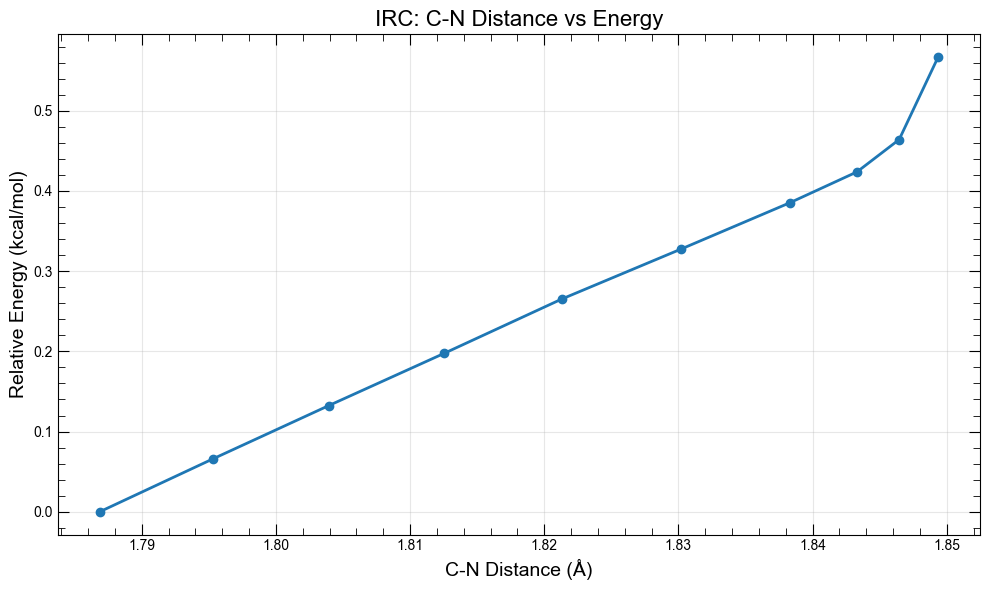

プロットを保存しました: irc_cn_distance.png


In [ ]:
# プロット
plt.figure(figsize=(10, 6))
plt.plot(distances, rel_energies_kcal, "o-", linewidth=2, markersize=6)
plt.xlabel("C-N Distance (Å)", fontsize=14)
plt.ylabel("Relative Energy (kcal/mol)", fontsize=14)
plt.title("IRC: C-N Distance vs Energy", fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("irc_cn_distance.png", dpi=300)
plt.show()

print("プロットを保存しました: irc_cn_distance.png")

In [12]:
# データの要約
min_idx = np.argmin(rel_energies_kcal)
max_idx = np.argmax(rel_energies_kcal)

print("\n=== データ要約 ===")
print(f"最小エネルギー点:")
print(f"  C-N距離: {distances[min_idx]:.4f} Å")
print(f"  相対エネルギー: {rel_energies_kcal[min_idx]:.2f} kcal/mol")
print(f"\n最大エネルギー点:")
print(f"  C-N距離: {distances[max_idx]:.4f} Å")
print(f"  相対エネルギー: {rel_energies_kcal[max_idx]:.2f} kcal/mol")
print(f"\nバリア高さ: {max(rel_energies_kcal):.2f} kcal/mol")


=== データ要約 ===
最小エネルギー点:
  C-N距離: 1.7869 Å
  相対エネルギー: 0.00 kcal/mol

最大エネルギー点:
  C-N距離: 1.8494 Å
  相対エネルギー: 0.57 kcal/mol

バリア高さ: 0.57 kcal/mol
